In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [6]:
data = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\new ds\crop_recomendation\Crop_recommendation.csv"
df = pd.read_csv(data)


In [7]:
df


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


In [8]:
df.shape


(2200, 8)

In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


In [10]:
df.describe()


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [4]:
df.isnull().sum()


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

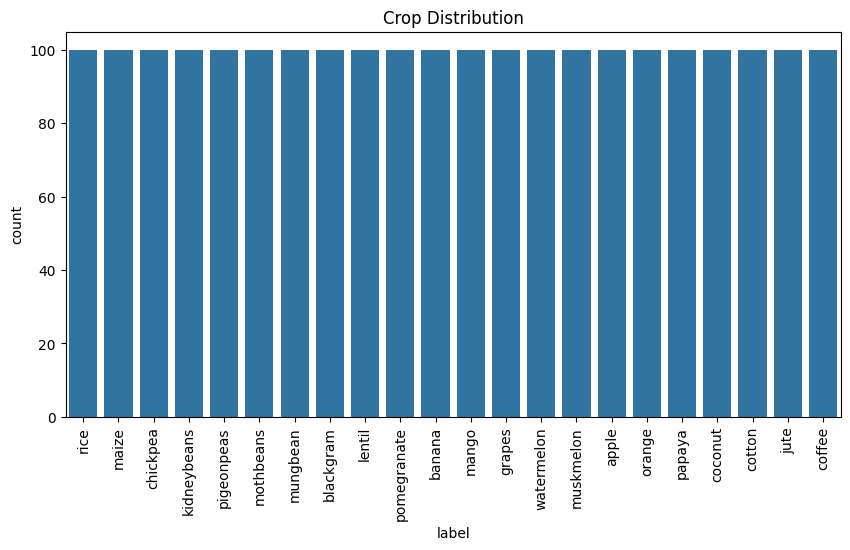

In [11]:
plt.figure(figsize=(10,5))
sns.countplot(x='label', data=df)
plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.show()


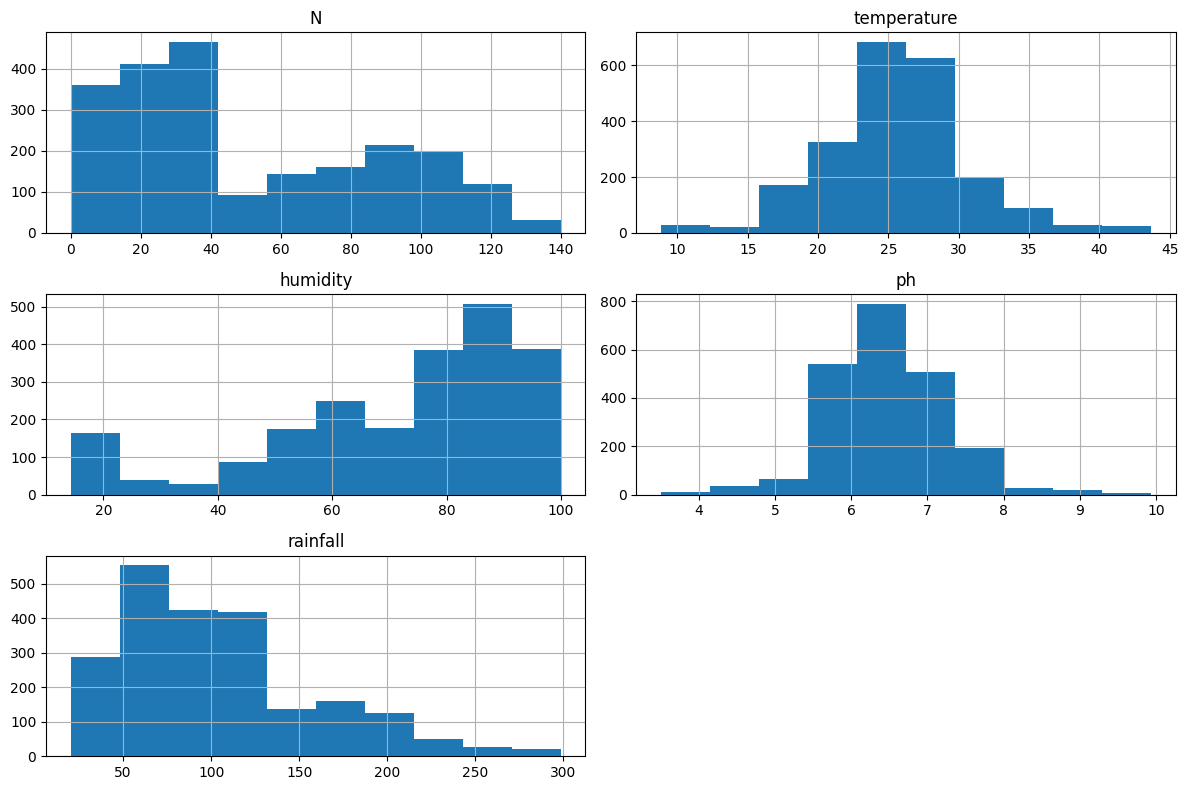

In [14]:
features = ['N', 'temperature', 'humidity', 'ph', 'rainfall']

df[features].hist(figsize=(12,8))
plt.tight_layout()
plt.show()


In [19]:
df[['N', 'humidity', 'rainfall']].skew()


N           0.509721
humidity   -1.091708
rainfall    0.965756
dtype: float64

In [23]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

df[['N', 'humidity', 'rainfall']] = pt.fit_transform(
    df[['N', 'humidity', 'rainfall']]
)


In [24]:
df[['N', 'humidity', 'rainfall']].skew()


N          -0.119860
humidity   -0.046786
rainfall   -0.025925
dtype: float64

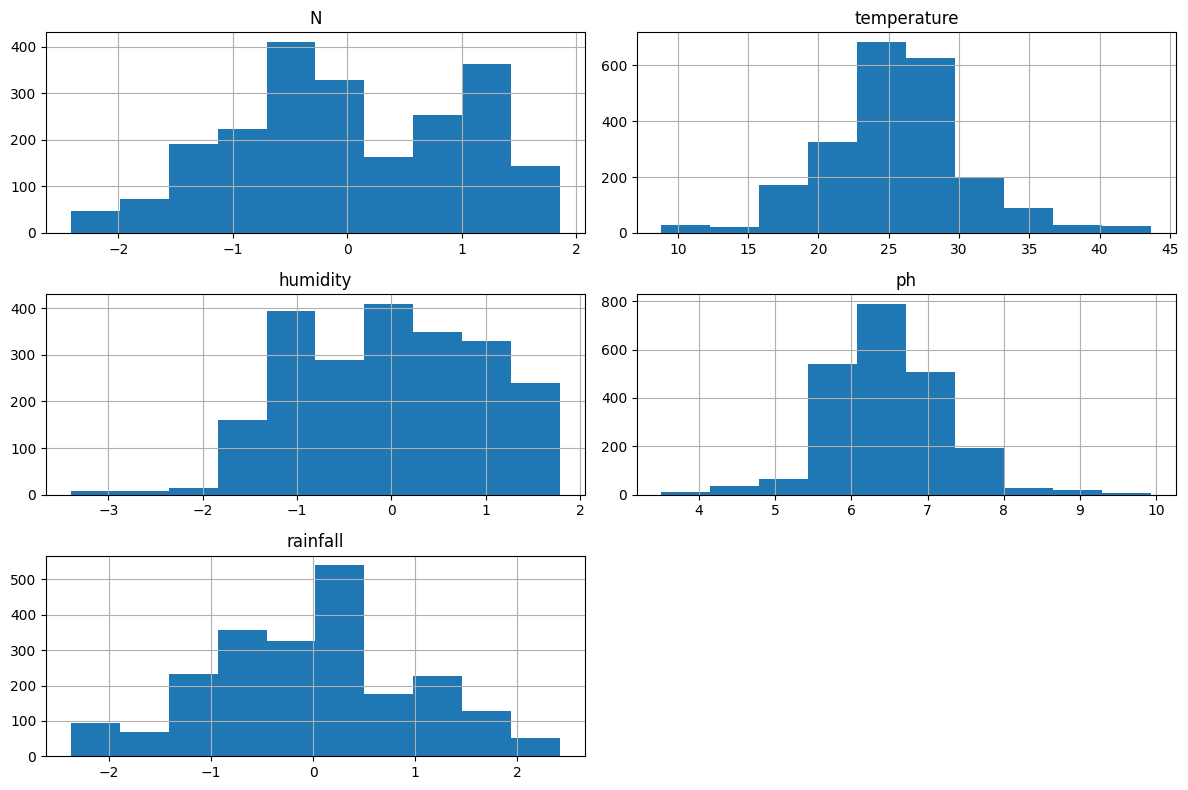

In [25]:
features = ['N', 'temperature', 'humidity', 'ph', 'rainfall']

df[features].hist(figsize=(12,8))
plt.tight_layout()
plt.show()


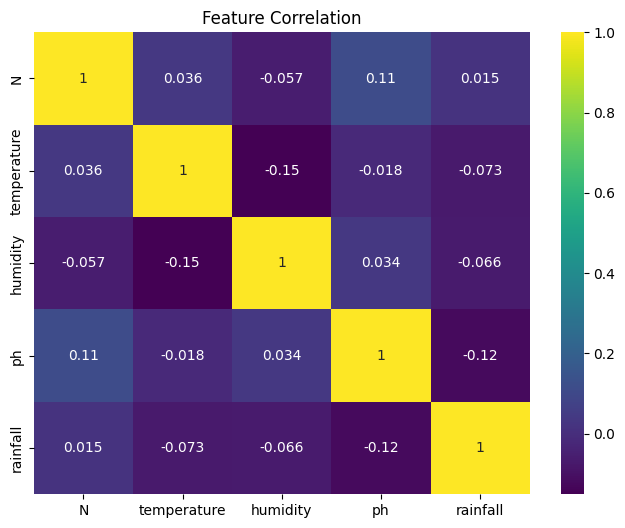

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(df[features].corr(), annot=True, cmap='viridis')
plt.title("Feature Correlation")
plt.show()


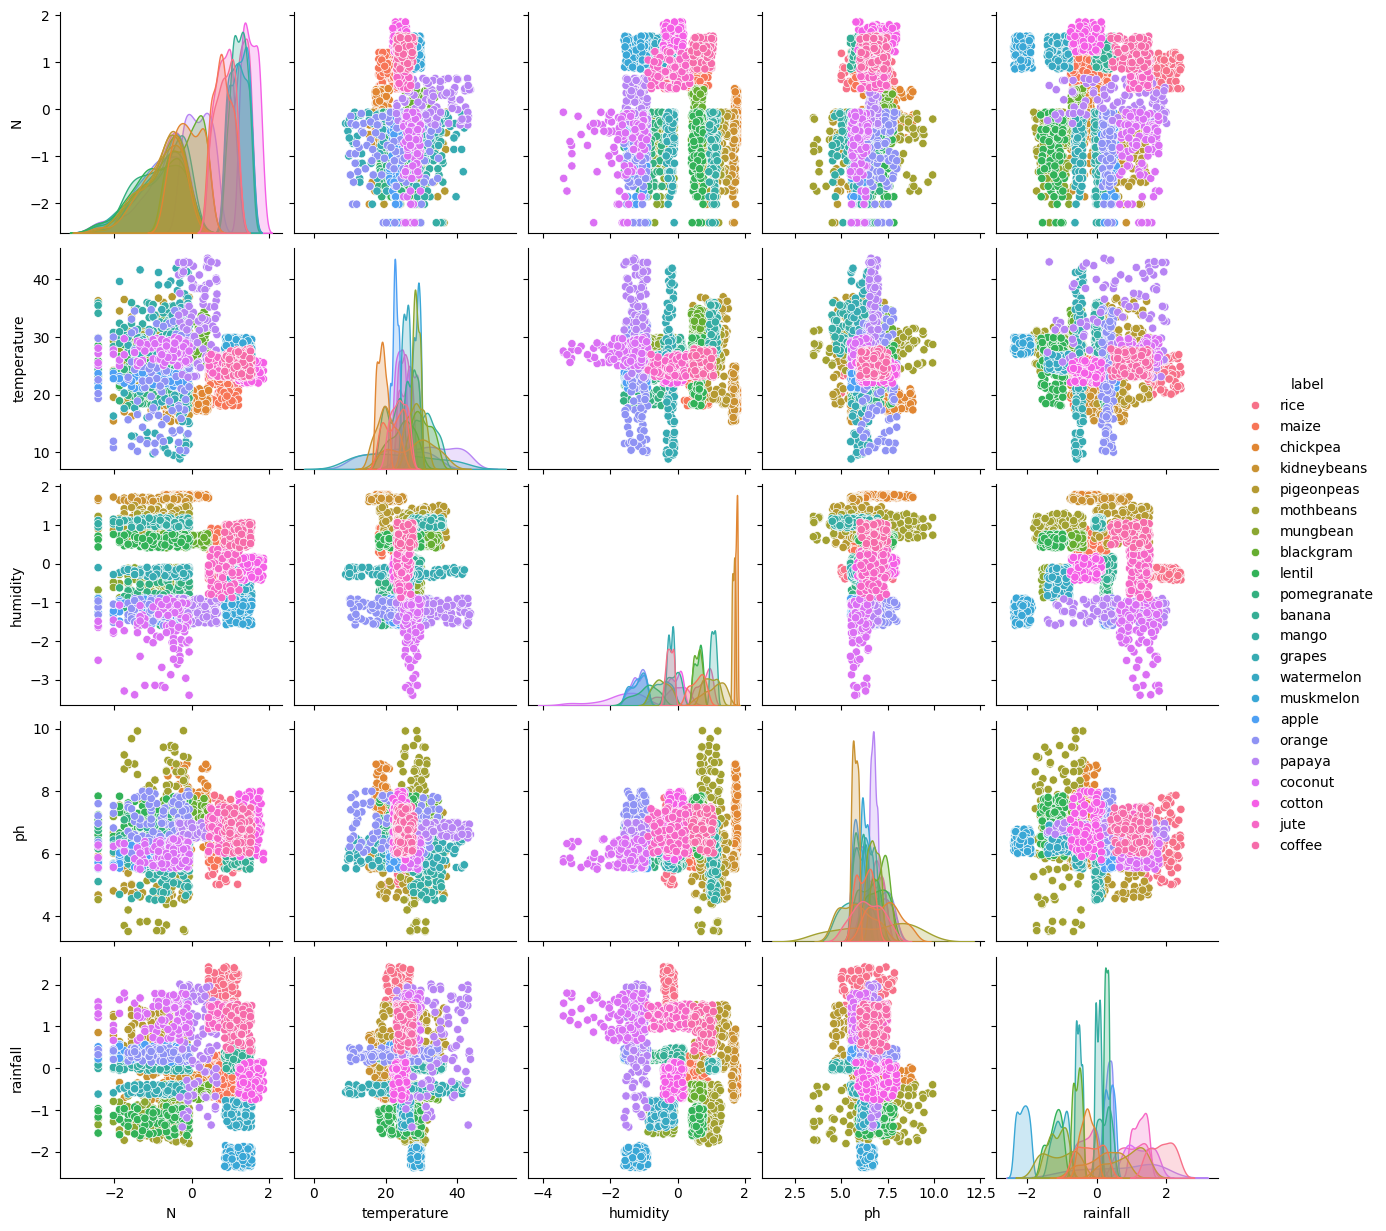

In [27]:
sns.pairplot(df, hue='label', vars=features)
plt.show()


In [28]:
X = df[['N', 'temperature', 'humidity', 'ph', 'rainfall']]
y = df['label']


In [29]:
le = LabelEncoder()
y = le.fit_transform(y)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [32]:
lr = LogisticRegression(max_iter=200)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.8477272727272728


In [33]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Accuracy: 0.9659090909090909


In [34]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.9681818181818181


In [35]:
print("LR:", accuracy_score(y_test, y_pred_lr))
print("DT:", accuracy_score(y_test, y_pred_dt))
print("RF:", accuracy_score(y_test, y_pred_rf))


LR: 0.8477272727272728
DT: 0.9659090909090909
RF: 0.9681818181818181


In [36]:
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.96      0.96      0.96        23
           1       1.00      0.90      0.95        21
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       0.89      1.00      0.94        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.85      1.00      0.92        11
          11       1.00      1.00      1.00        21
          12       0.86      1.00      0.93        19
          13       1.00      0.88      0.93        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       0.86      0.86      0.86        14
          17       1.00    

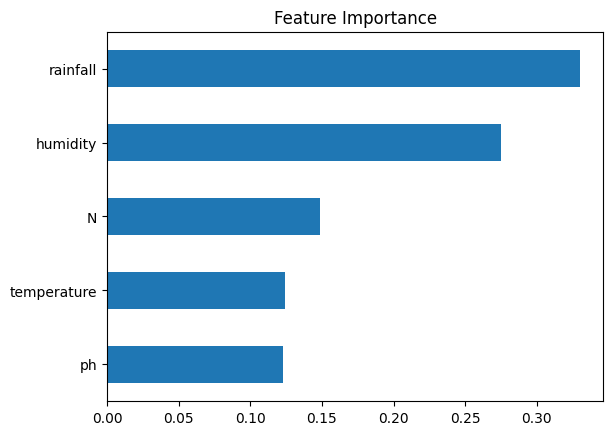

In [37]:
importances = rf.feature_importances_

feat_imp = pd.Series(importances, index=X.columns)

feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()


In [41]:
sample = [[90, 25, 80, 6.5, 200]]

pred = rf.predict(sample)

print("Recommended Crop:", le.inverse_transform(pred)[0])


Recommended Crop: coffee


c:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\ML\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [46]:
import joblib
import os

# Create folder if not exists
os.makedirs("model", exist_ok=True)

# Save files inside folder
joblib.dump(rf, "model/crop_model.pkl")


['model/crop_model.pkl']

In [47]:
joblib.dump(scaler,"scalar.pkl")


['scalar.pkl']

In [48]:
joblib.dump(le,"label_encoder.pkl")


['label_encoder.pkl']